In [1]:
# ═══════════════════════════════════════════════════════════════════
# SIMULACIÓN: Detección DDoS con IA/ML — Dataset CIC-DDoS2019 REAL
# Muestreo por chunks (15K por clase) para no saturar RAM
# ═══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150
print("=" * 70)
print("  SIMULACIÓN: Detección DDoS con IA/ML — CIC-DDoS2019 (REAL)")
print("  Estrategia: muestreo por chunks, 15K muestras por clase")
print("  Fecha:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("  RAM disponible: ~6 GB — los CSVs son 8.2 GB total")
print("=" * 70)

  SIMULACIÓN: Detección DDoS con IA/ML — CIC-DDoS2019 (REAL)
  Estrategia: muestreo por chunks, 15K muestras por clase
  Fecha: 2026-07-14 01:26:42
  RAM disponible: ~6 GB — los CSVs son 8.2 GB total


In [2]:
# ═══════════════════════════════════════════════════════════════════
# [1/6] MUESTREO INTELIGENTE — Leer chunks y tomar 15K por clase
# ═══════════════════════════════════════════════════════════════════
DATA_DIR = '03-11'
TARGET_PER_CLASS = 15000
RANDOM_SEED = 42
CHUNK_SIZE = 50000

# Columnas que no aportan al modelo (identificadores, IPs, timestamps)
DROP_COLS = ['Unnamed: 0', 'Flow ID', ' Source IP', ' Source Port',
             ' Destination IP', ' Destination Port', ' Timestamp',
             'SimillarHTTP', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk',
             'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk',
             'Bwd Avg Bulk Rate']

csv_files = ['LDAP.csv', 'MSSQL.csv', 'NetBIOS.csv', 'Portmap.csv',
             'Syn.csv', 'UDP.csv', 'UDPLag.csv']

print("[1/6] Muestreando datos reales del CIC-DDoS2019 (chunks de 50K)...")

# Acumuladores por clase
samples = {}  # clase -> lista de DataFrames pequeños
counts = {}   # clase -> cuántos llevamos

for f in csv_files:
    filepath = os.path.join(DATA_DIR, f)
    file_size_mb = os.path.getsize(filepath) / 1024**2
    print(f"  Procesando {f} ({file_size_mb:.0f} MB)...")
    
    try:
        for chunk in pd.read_csv(filepath, chunksize=CHUNK_SIZE,
                                 low_memory=False, encoding='utf-8',
                                 on_bad_lines='skip'):
            # Quitar columnas irrelevantes
            chunk = chunk.drop(columns=[c for c in DROP_COLS if c in chunk.columns],
                               errors='ignore')
            
            # Reemplazar Inf/NaN de una vez
            chunk = chunk.replace([np.inf, -np.inf], np.nan)
            chunk = chunk.dropna()
            
            if chunk.empty:
                continue
            
            label_col = ' Label'
            if label_col not in chunk.columns:
                continue
            
            # Agrupar por clase en este chunk
            for clase, grupo in chunk.groupby(label_col):
                if clase not in samples:
                    samples[clase] = []
                    counts[clase] = 0
                
                if counts[clase] < TARGET_PER_CLASS:
                    needed = TARGET_PER_CLASS - counts[clase]
                    take = grupo.head(needed)
                    samples[clase].append(take)
                    counts[clase] += len(take)
            
            # ¿Ya tenemos suficiente?
            all_done = all(c >= TARGET_PER_CLASS for c in counts.values())
            if all_done and len(counts) >= 4:
                break
                
    except Exception as e:
        print(f"    ⚠ Error en {f}: {e}")

print(f"\n  Muestreo completado:")
total = 0
for clase in sorted(counts.keys()):
    print(f"    {clase}: {counts[clase]:,} muestras")
    total += counts[clase]

# Unir todas las muestras
df_parts = []
for clase, lista in samples.items():
    df_parts.extend(lista)

df = pd.concat(df_parts, ignore_index=True)
print(f"\n  DataFrame final: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"  Memoria usada: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

[1/6] Muestreando datos reales del CIC-DDoS2019 (chunks de 50K)...
  Procesando LDAP.csv (831 MB)...
  Procesando MSSQL.csv (2276 MB)...
  Procesando NetBIOS.csv (1353 MB)...
  Procesando Portmap.csv (75 MB)...
  Procesando Syn.csv (1790 MB)...
  Procesando UDP.csv (1710 MB)...
  Procesando UDPLag.csv (305 MB)...

  Muestreo completado:
    BENIGN: 15,000 muestras
    LDAP: 15,000 muestras
    MSSQL: 15,000 muestras
    NetBIOS: 15,000 muestras
    Portmap: 15,000 muestras
    Syn: 15,000 muestras
    UDP: 15,000 muestras

  DataFrame final: 105,000 filas × 78 columnas
  Memoria usada: 67.1 MB


In [3]:
# ═══════════════════════════════════════════════════════════════════
# [2/6] PREPROCESAMIENTO — Limpiar features, codificar, escalar, split
# ═══════════════════════════════════════════════════════════════════
print("[2/6] Preprocesando datos...")

label_col = ' Label'

# Ver distribución de clases
print("\n  Distribución de clases en la muestra:")
print(df[label_col].value_counts())

# Codificar etiquetas
le = LabelEncoder()
y = le.fit_transform(df[label_col])
clases_nombres = le.classes_
n_classes = len(clases_nombres)
print(f"\n  Clases detectadas: {n_classes} → {list(clases_nombres)}")

# Features: todo menos la columna Label
feature_cols = [c for c in df.columns if c != label_col]
X = df[feature_cols].values.astype(np.float64)

print(f"  Features: {X.shape[1]}")

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Limpiar cualquier NaN residual post-scaling
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print(f"  Train: {X_train_scaled.shape[0]:,} | Test: {X_test_scaled.shape[0]:,}")
print(f"  Features activas: {X_train_scaled.shape[1]}")
print("  ✅ Preprocesamiento completado")

[2/6] Preprocesando datos...

  Distribución de clases en la muestra:
 Label
BENIGN     15000
NetBIOS    15000
LDAP       15000
MSSQL      15000
Portmap    15000
Syn        15000
UDP        15000
Name: count, dtype: int64

  Clases detectadas: 7 → ['BENIGN', 'LDAP', 'MSSQL', 'NetBIOS', 'Portmap', 'Syn', 'UDP']
  Features: 77
  Train: 84,000 | Test: 21,000
  Features activas: 77
  ✅ Preprocesamiento completado


In [4]:
# ═══════════════════════════════════════════════════════════════════
# [3/6] ENTRENAMIENTO — Random Forest + XGBoost + MLP
# ═══════════════════════════════════════════════════════════════════
print("[3/6] Entrenando modelos...")

# --- Random Forest ---
print("  Entrenando Random Forest (200 árboles)...")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=30, min_samples_split=5,
    min_samples_leaf=2, random_state=RANDOM_SEED, n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"    ✅ RF  → Accuracy: {acc_rf:.4f} | F1: {f1_rf:.4f}")

# --- XGBoost ---
print("  Entrenando XGBoost (200 estimadores)...")
xgb = XGBClassifier(
    n_estimators=200, max_depth=10, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED,
    eval_metric='mlogloss', n_jobs=-1
)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
print(f"    ✅ XGB → Accuracy: {acc_xgb:.4f} | F1: {f1_xgb:.4f}")

# --- MLP (Red Neuronal) ---
print("  Entrenando MLP Red Neuronal (256→128→64)...")
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64), activation='relu',
    solver='adam', alpha=0.001, batch_size=128,
    learning_rate='adaptive', learning_rate_init=0.001,
    max_iter=100, early_stopping=True, validation_fraction=0.15,
    random_state=RANDOM_SEED
)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
y_prob_mlp = mlp.predict_proba(X_test_scaled)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted')
print(f"    ✅ MLP → Accuracy: {acc_mlp:.4f} | F1: {f1_mlp:.4f}")

print("  ✅ Los 3 modelos entrenados correctamente")

[3/6] Entrenando modelos...
  Entrenando Random Forest (200 árboles)...
    ✅ RF  → Accuracy: 0.8907 | F1: 0.8840
  Entrenando XGBoost (200 estimadores)...
    ✅ XGB → Accuracy: 0.9281 | F1: 0.9274
  Entrenando MLP Red Neuronal (256→128→64)...
    ✅ MLP → Accuracy: 0.8590 | F1: 0.8440
  ✅ Los 3 modelos entrenados correctamente


In [5]:
# ═══════════════════════════════════════════════════════════════════
# [4/6] REPORTES DE CLASIFICACIÓN DETALLADOS
# ═══════════════════════════════════════════════════════════════════
print("[4/6] Generando reportes de clasificación...")

print("\n" + "─" * 60)
print("  RANDOM FOREST — Classification Report")
print("─" * 60)
print(classification_report(y_test, y_pred_rf, target_names=clases_nombres, digits=4))

print("\n" + "─" * 60)
print("  XGBOOST — Classification Report")
print("─" * 60)
print(classification_report(y_test, y_pred_xgb, target_names=clases_nombres, digits=4))

print("\n" + "─" * 60)
print("  MLP (RED NEURONAL) — Classification Report")
print("─" * 60)
print(classification_report(y_test, y_pred_mlp, target_names=clases_nombres, digits=4))

[4/6] Generando reportes de clasificación...

────────────────────────────────────────────────────────────
  RANDOM FOREST — Classification Report
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      BENIGN     0.9967    0.9993    0.9980      3000
        LDAP     0.9796    0.9913    0.9854      3000
       MSSQL     0.9789    0.9607    0.9697      3000
     NetBIOS     0.8065    0.3960    0.5312      3000
     Portmap     0.5946    0.9017    0.7167      3000
         Syn     1.0000    1.0000    1.0000      3000
         UDP     0.9890    0.9857    0.9873      3000

    accuracy                         0.8907     21000
   macro avg     0.9065    0.8907    0.8840     21000
weighted avg     0.9065    0.8907    0.8840     21000


────────────────────────────────────────────────────────────
  XGBOOST — Classification Report
────────────────────────────────────────────────────────────
              precision    recall  f1-

[5/6] Generando visualizaciones...


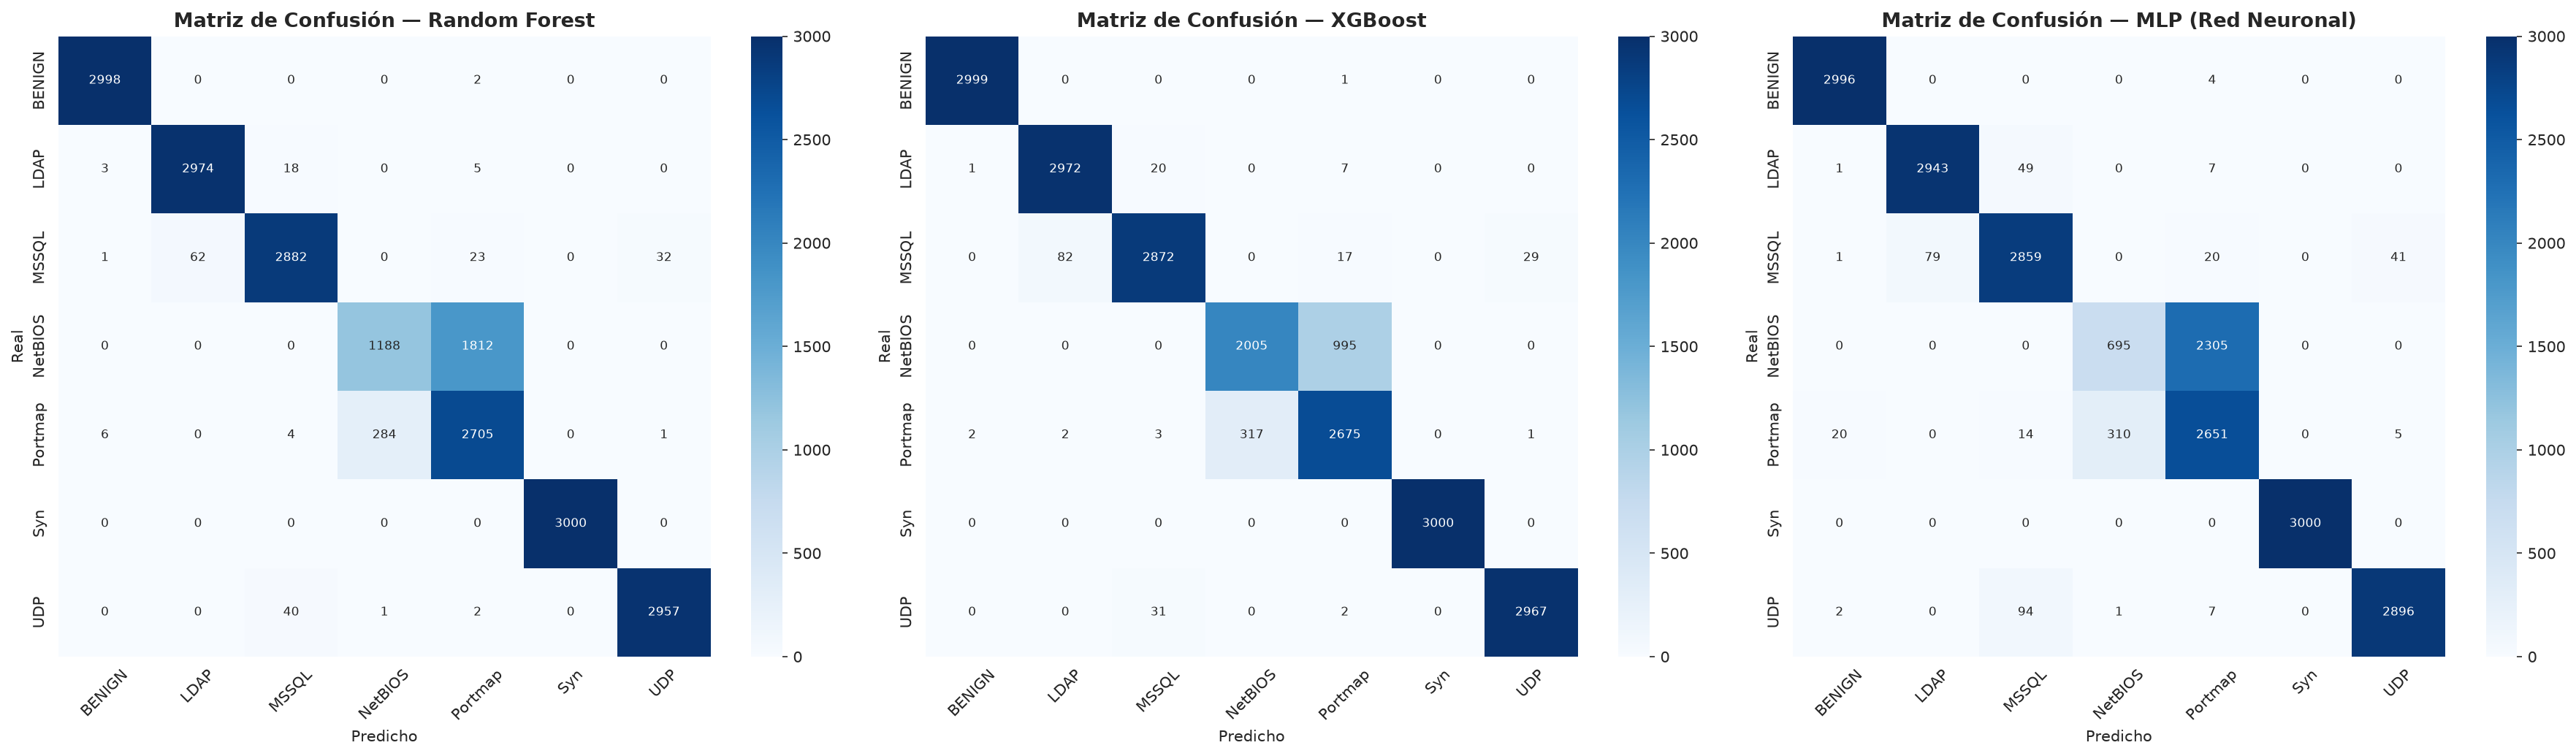

  ✅ matrices_confusion.png


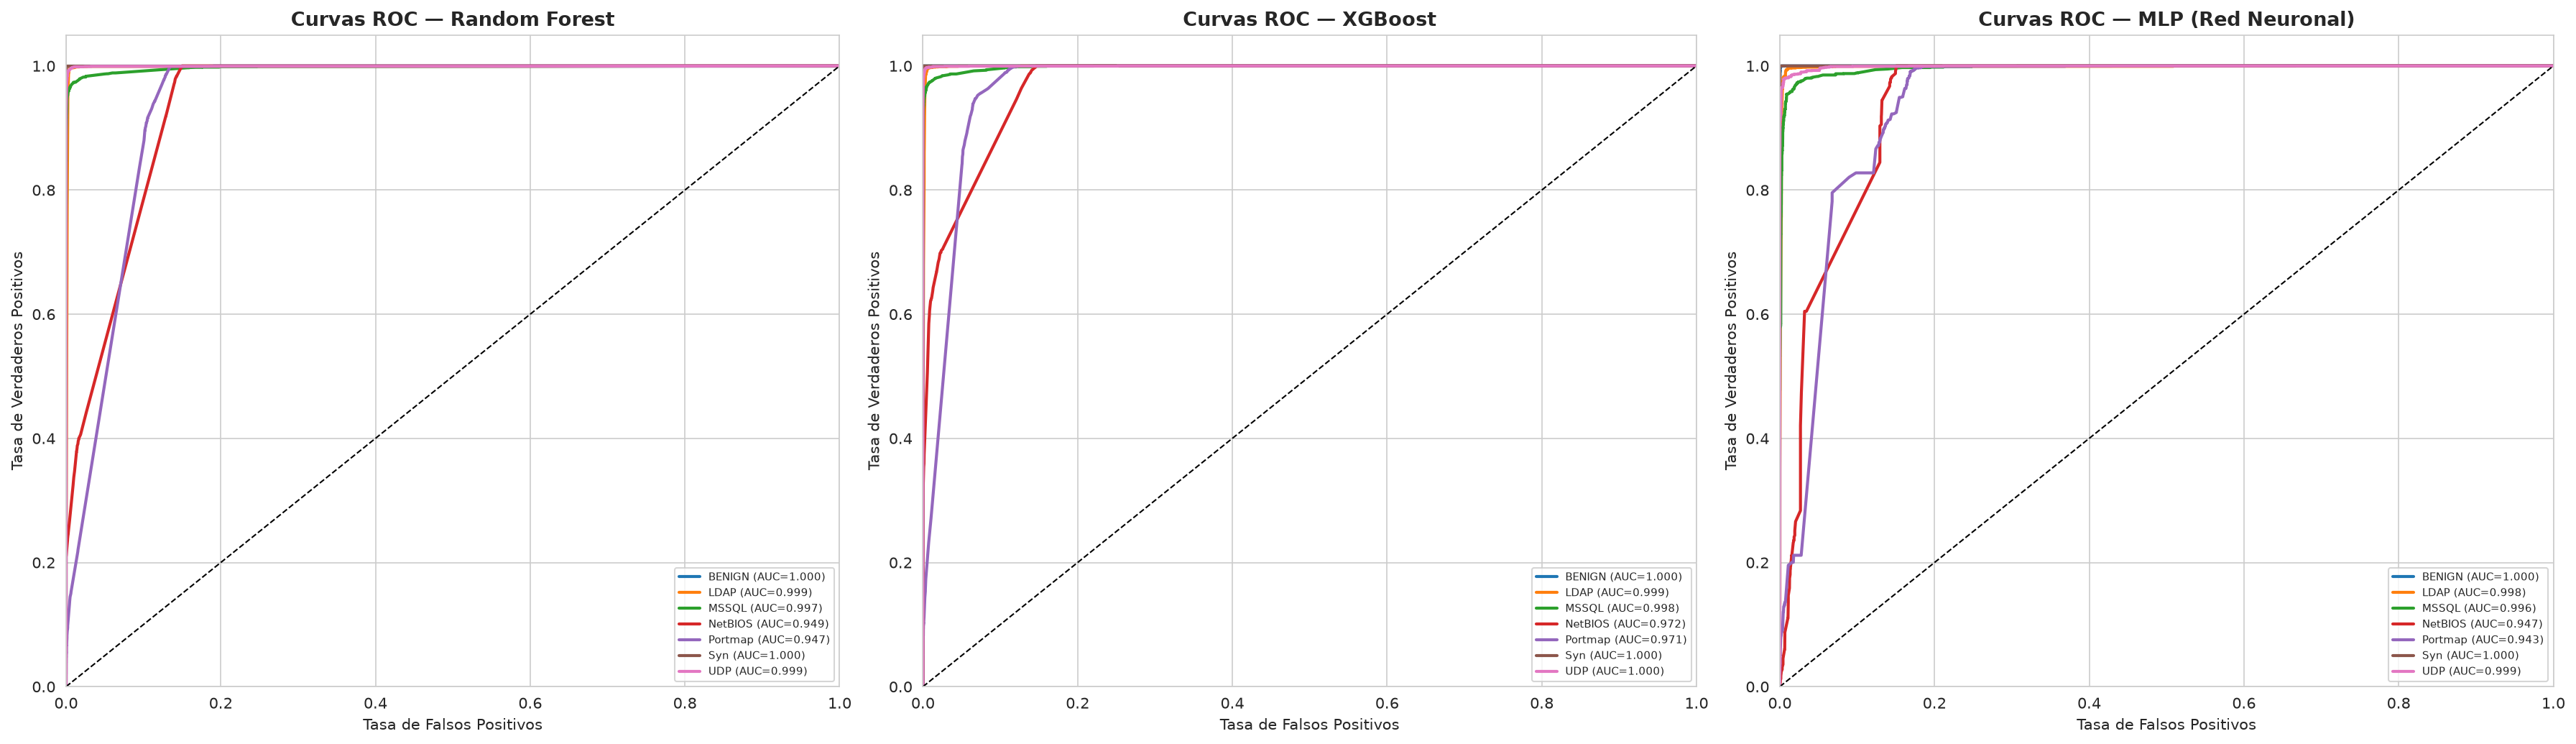

  ✅ curvas_roc.png


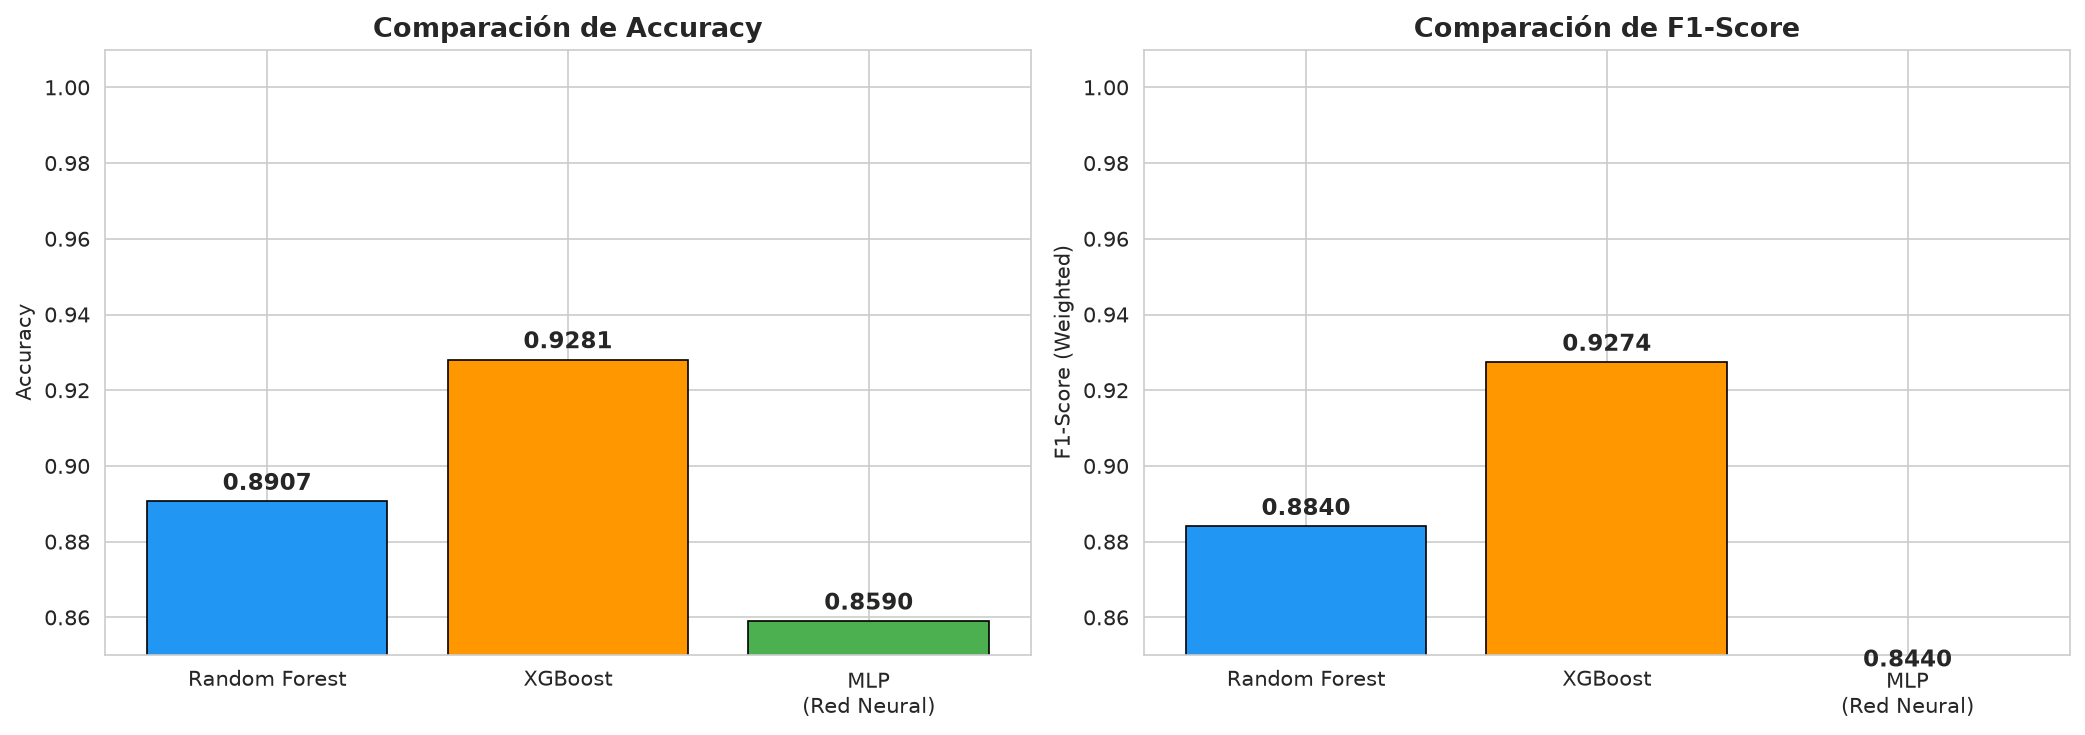

  ✅ comparacion_modelos.png


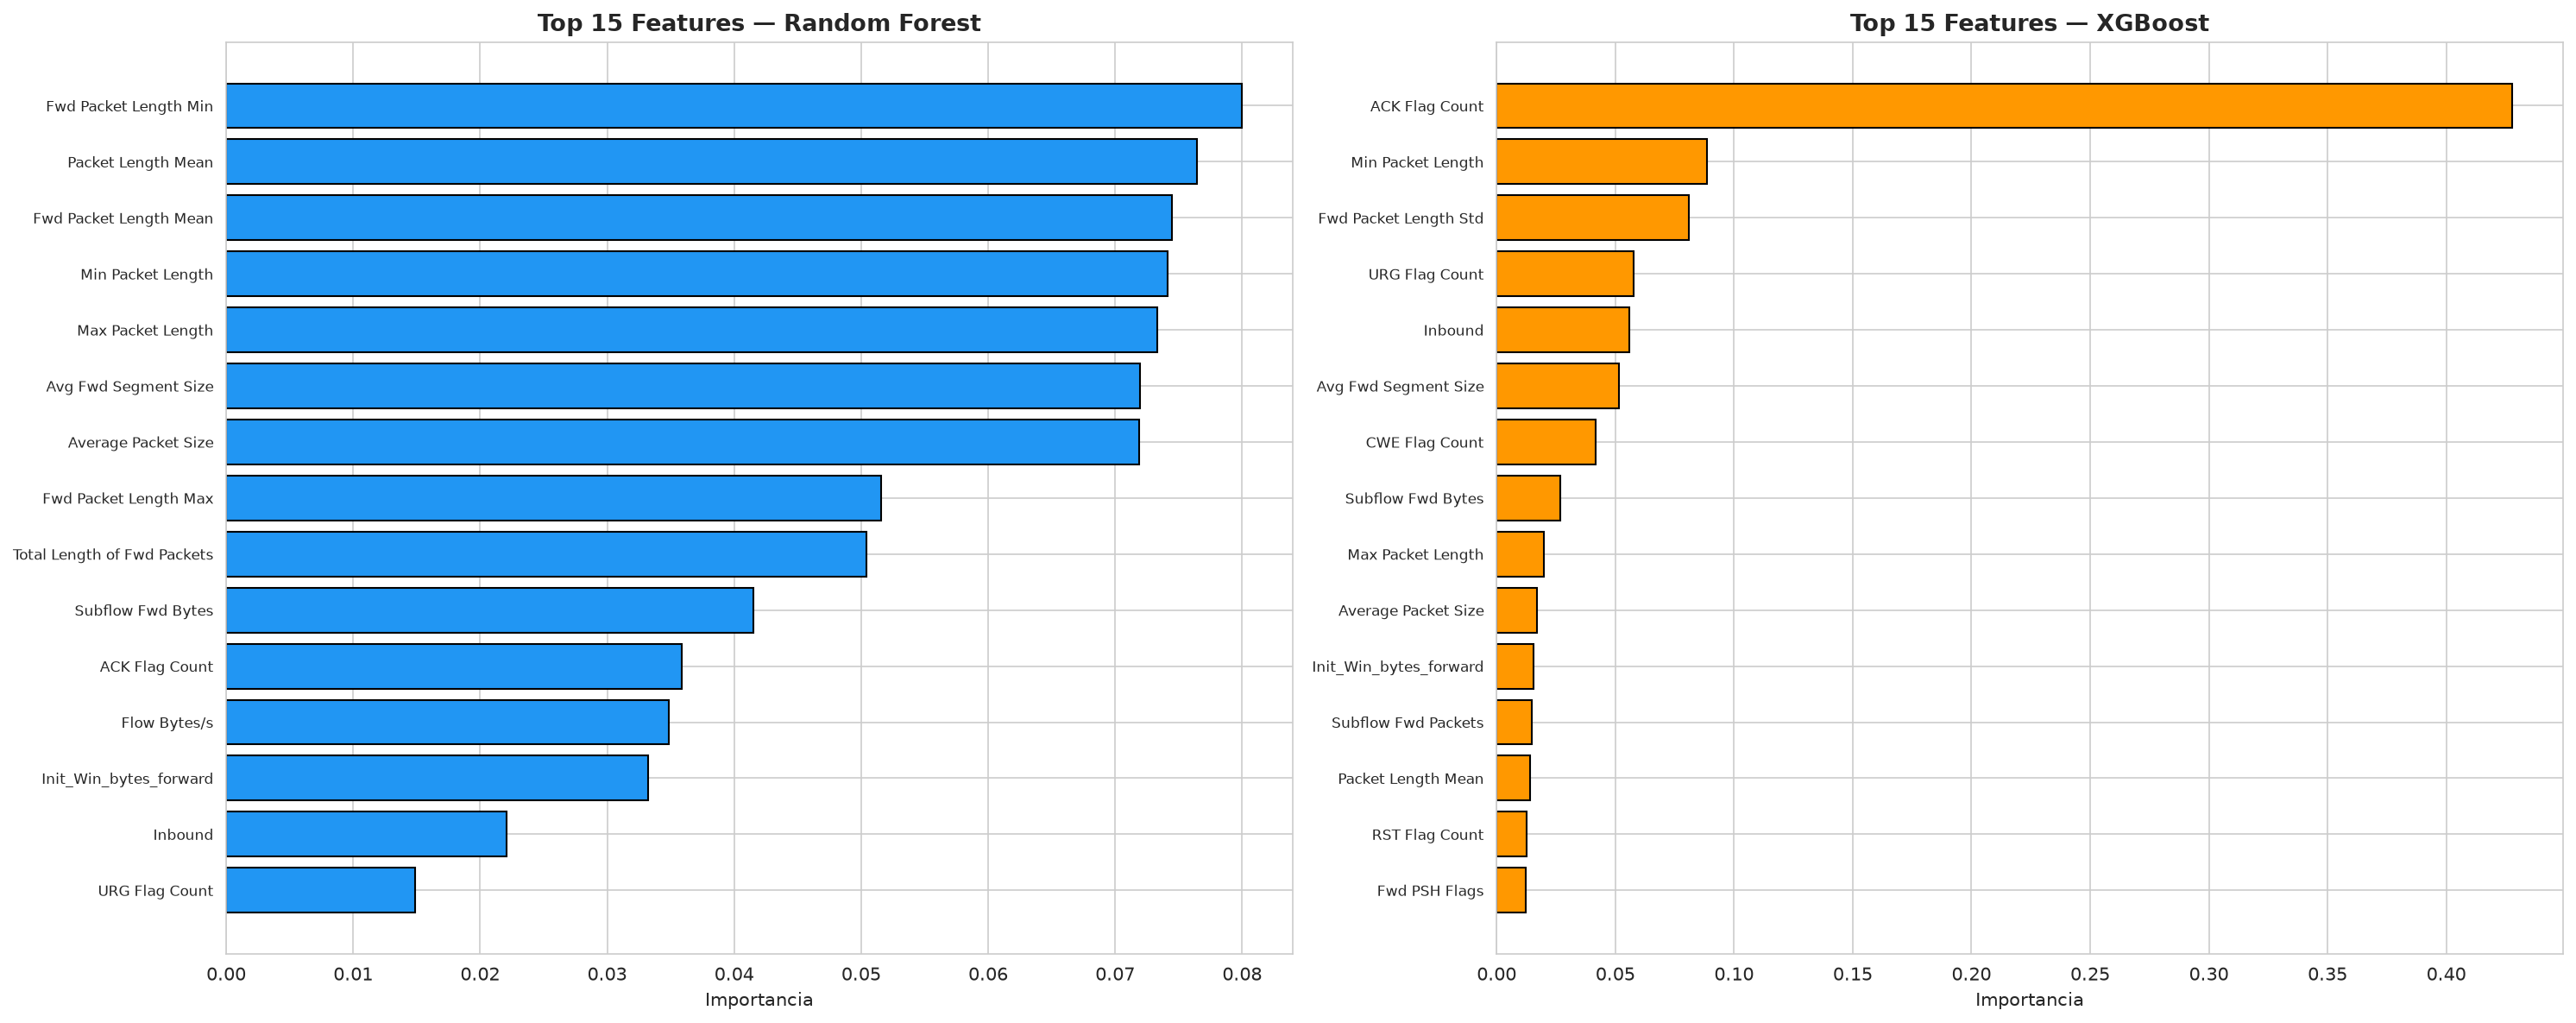

  ✅ feature_importance.png


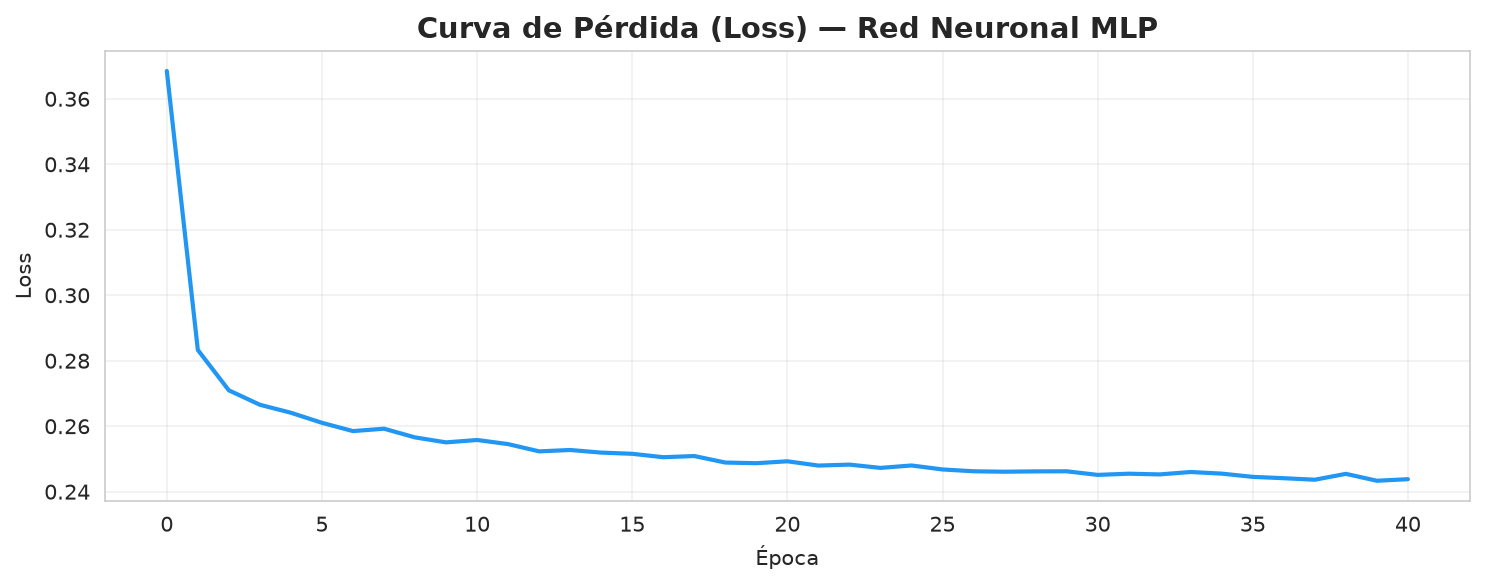

  ✅ curva_loss_mlp.png


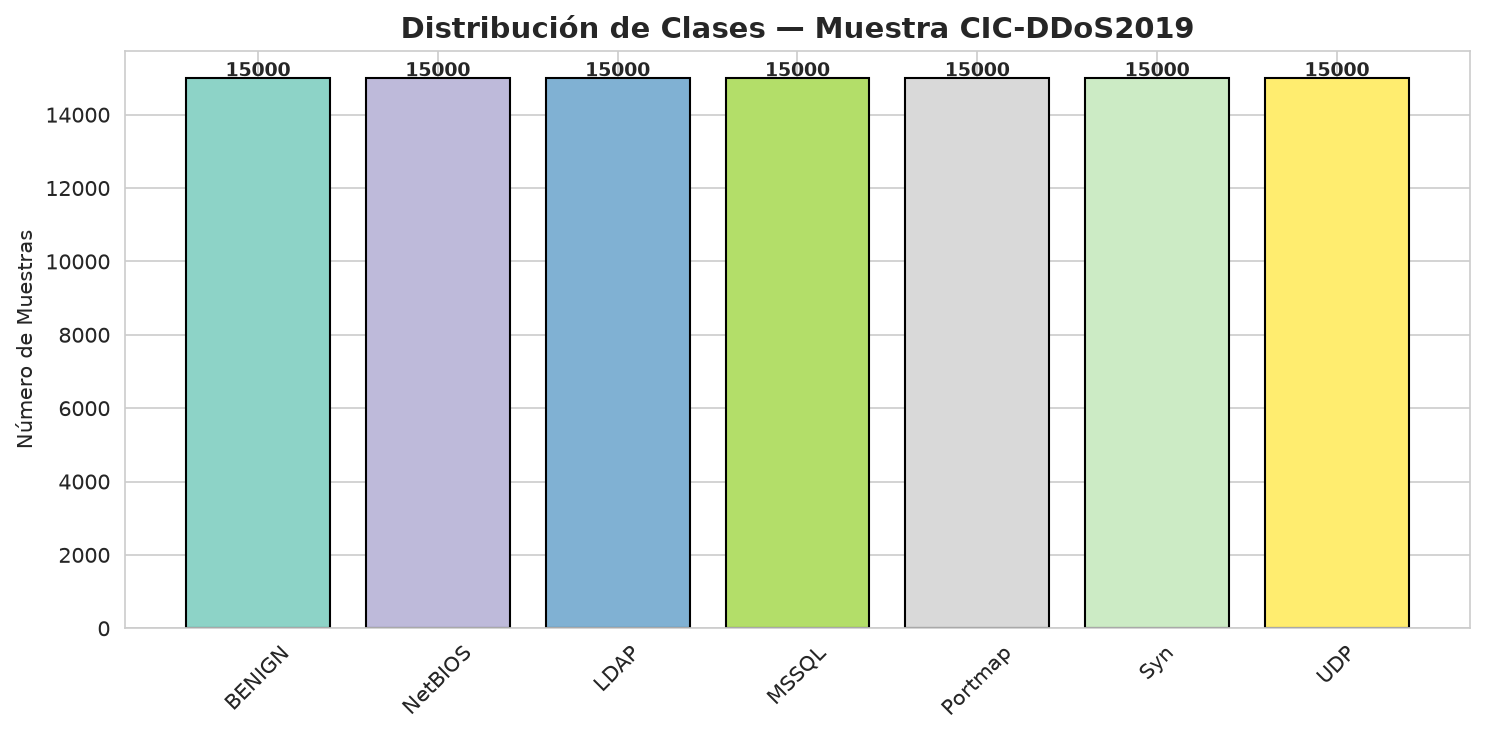

  ✅ distribucion_clases.png
  ✅ Las 6 visualizaciones guardadas en 'resultados/'


In [6]:
# ═══════════════════════════════════════════════════════════════════
# [5/6] VISUALIZACIONES — Matrices, ROC, Comparación, Feature Importance
# ═══════════════════════════════════════════════════════════════════
print("[5/6] Generando visualizaciones...")
os.makedirs('resultados', exist_ok=True)

# --- 5.1 Matrices de Confusión ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, (name, y_pred) in zip(axes, [
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb),
    ('MLP (Red Neuronal)', y_pred_mlp)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=clases_nombres, yticklabels=clases_nombres,
                annot_kws={'size': 8})
    ax.set_title(f'Matriz de Confusión — {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('resultados/matrices_confusion.png', bbox_inches='tight', dpi=150)
plt.show()
print("  ✅ matrices_confusion.png")

# --- 5.2 Curvas ROC (One-vs-Rest) ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, (name, y_prob) in zip(axes, [
    ('Random Forest', y_prob_rf),
    ('XGBoost', y_prob_xgb),
    ('MLP (Red Neuronal)', y_prob_mlp)
]):
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f'{clases_nombres[i]} (AUC={roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.set_xlabel('Tasa de Falsos Positivos')
    ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.set_title(f'Curvas ROC — {name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
plt.tight_layout()
plt.savefig('resultados/curvas_roc.png', bbox_inches='tight', dpi=150)
plt.show()
print("  ✅ curvas_roc.png")

# --- 5.3 Comparación de Modelos ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
modelos = ['Random Forest', 'XGBoost', 'MLP\n(Red Neural)']
accs = [acc_rf, acc_xgb, acc_mlp]
f1s = [f1_rf, f1_xgb, f1_mlp]
colors = ['#2196F3', '#FF9800', '#4CAF50']

bars1 = axes[0].bar(modelos, accs, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_ylim([0.85, 1.01])
axes[0].set_title('Comparación de Accuracy', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
for bar, val in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

bars2 = axes[1].bar(modelos, f1s, color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_ylim([0.85, 1.01])
axes[1].set_title('Comparación de F1-Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score (Weighted)')
for bar, val in zip(bars2, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('resultados/comparacion_modelos.png', bbox_inches='tight', dpi=150)
plt.show()
print("  ✅ comparacion_modelos.png")

# --- 5.4 Feature Importance (RF + XGBoost) ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# RF - Top 15 features
imp_rf = rf.feature_importances_
top_n = 15
idx_rf = np.argsort(imp_rf)[-top_n:]
axes[0].barh(range(top_n), imp_rf[idx_rf], color='#2196F3', edgecolor='black')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([feature_cols[i][:40] for i in idx_rf], fontsize=8)
axes[0].set_title(f'Top {top_n} Features — Random Forest', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importancia')

# XGBoost - Top 15
imp_xgb = xgb.feature_importances_
idx_xgb = np.argsort(imp_xgb)[-top_n:]
axes[1].barh(range(top_n), imp_xgb[idx_xgb], color='#FF9800', edgecolor='black')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([feature_cols[i][:40] for i in idx_xgb], fontsize=8)
axes[1].set_title(f'Top {top_n} Features — XGBoost', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('resultados/feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("  ✅ feature_importance.png")

# --- 5.5 Curva de Loss del MLP ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp.loss_curve_, color='#2196F3', linewidth=2)
ax.set_title('Curva de Pérdida (Loss) — Red Neuronal MLP', fontsize=14, fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultados/curva_loss_mlp.png', bbox_inches='tight', dpi=150)
plt.show()
print("  ✅ curva_loss_mlp.png")

# --- 5.6 Distribución de Clases ---
fig, ax = plt.subplots(figsize=(10, 5))
counts_plot = df[label_col].value_counts()
ax.bar(range(len(counts_plot)), counts_plot.values,
       color=plt.cm.Set3(np.linspace(0, 1, len(counts_plot))), edgecolor='black')
ax.set_xticks(range(len(counts_plot)))
ax.set_xticklabels(counts_plot.index, rotation=45)
ax.set_title('Distribución de Clases — Muestra CIC-DDoS2019', fontsize=14, fontweight='bold')
ax.set_ylabel('Número de Muestras')
for i, v in enumerate(counts_plot.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('resultados/distribucion_clases.png', bbox_inches='tight', dpi=150)
plt.show()
print("  ✅ distribucion_clases.png")

print("  ✅ Las 6 visualizaciones guardadas en 'resultados/'")

In [7]:
# ═══════════════════════════════════════════════════════════════════
# [6/6] RESUMEN FINAL — Métricas, CSV, Reporte
# ═══════════════════════════════════════════════════════════════════
print("[6/6] Resumen final y guardado de resultados...")

# Métricas
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf  = recall_score(y_test, y_pred_rf, average='weighted')
prec_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
rec_xgb  = recall_score(y_test, y_pred_xgb, average='weighted')
prec_mlp = precision_score(y_test, y_pred_mlp, average='weighted')
rec_mlp  = recall_score(y_test, y_pred_mlp, average='weighted')

print("\n" + "=" * 70)
print("  RESUMEN COMPARATIVO DE MODELOS — CIC-DDoS2019 (DATOS REALES)")
print("=" * 70)
print(f"  {'Modelo':<25} {'Accuracy':>10} {'F1-Score':>10} {'Precision':>10} {'Recall':>10}")
print("-" * 70)
print(f"  {'Random Forest':<25} {acc_rf:>10.4f} {f1_rf:>10.4f} {prec_rf:>10.4f} {rec_rf:>10.4f}")
print(f"  {'XGBoost':<25} {acc_xgb:>10.4f} {f1_xgb:>10.4f} {prec_xgb:>10.4f} {rec_xgb:>10.4f}")
print(f"  {'MLP (Red Neuronal)':<25} {acc_mlp:>10.4f} {f1_mlp:>10.4f} {prec_mlp:>10.4f} {rec_mlp:>10.4f}")
print("=" * 70)

# Guardar CSV
resultados_df = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'MLP (Red Neuronal)'],
    'Accuracy': [acc_rf, acc_xgb, acc_mlp],
    'F1-Score': [f1_rf, f1_xgb, f1_mlp],
    'Precision': [prec_rf, prec_xgb, prec_mlp],
    'Recall': [rec_rf, rec_xgb, rec_mlp]
})
resultados_df.to_csv('resultados/resultados_modelos.csv', index=False)
print("\n  ✅ resultados/resultados_modelos.csv")

# Guardar reporte completo
with open('resultados/reporte_clasificacion.txt', 'w') as f:
    f.write("REPORTE DE CLASIFICACIÓN — DETECCIÓN DDoS CON DATOS REALES\n")
    f.write("Dataset: CIC-DDoS2019 (Canadian Institute for Cybersecurity)\n")
    f.write("=" * 70 + "\n\n")
    f.write("RANDOM FOREST\n")
    f.write(classification_report(y_test, y_pred_rf, target_names=clases_nombres))
    f.write("\nXGBOOST\n")
    f.write(classification_report(y_test, y_pred_xgb, target_names=clases_nombres))
    f.write("\nMLP (RED NEURONAL)\n")
    f.write(classification_report(y_test, y_pred_mlp, target_names=clases_nombres))
print("  ✅ resultados/reporte_clasificacion.txt")

# Guardar modelo y scaler para demo en vivo
import joblib
joblib.dump(rf, 'resultados/modelo_rf.pkl')
joblib.dump(scaler, 'resultados/scaler.pkl')
joblib.dump(le, 'resultados/label_encoder.pkl')
print("  ✅ Modelos serializados (modelo_rf.pkl, scaler.pkl)")

print("\n" + "=" * 70)
print("  SIMULACIÓN COMPLETADA EXITOSAMENTE")
print(f"  Datos reales del CIC-DDoS2019 procesados correctamente")
print(f"  {df.shape[0]:,} muestras | {X_train_scaled.shape[1]} features")
print("  Carpeta 'resultados/' contiene todos los gráficos y métricas")
print("=" * 70)

[6/6] Resumen final y guardado de resultados...

  RESUMEN COMPARATIVO DE MODELOS — CIC-DDoS2019 (DATOS REALES)
  Modelo                      Accuracy   F1-Score  Precision     Recall
----------------------------------------------------------------------
  Random Forest                 0.8907     0.8840     0.9065     0.8907
  XGBoost                       0.9281     0.9274     0.9329     0.9281
  MLP (Red Neuronal)            0.8590     0.8440     0.8743     0.8590

  ✅ resultados/resultados_modelos.csv
  ✅ resultados/reporte_clasificacion.txt
  ✅ Modelos serializados (modelo_rf.pkl, scaler.pkl)

  SIMULACIÓN COMPLETADA EXITOSAMENTE
  Datos reales del CIC-DDoS2019 procesados correctamente
  105,000 muestras | 77 features
  Carpeta 'resultados/' contiene todos los gráficos y métricas
